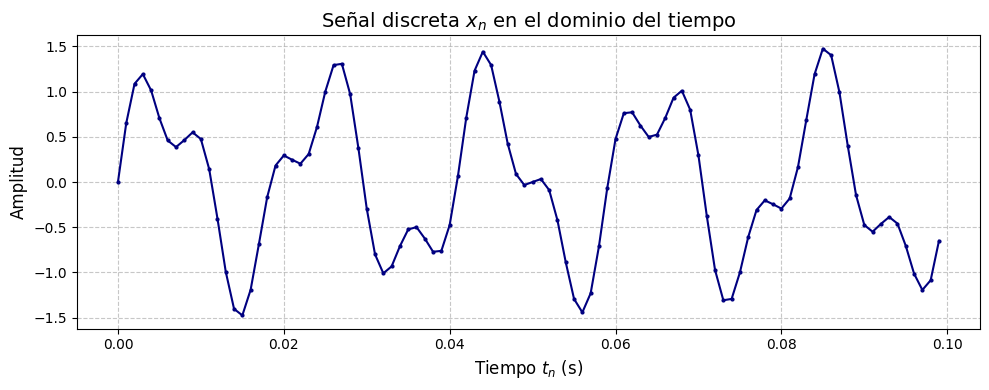

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de las ondas (neskuit nos vigila desde el más allá)
f1 = 50.0   # Hz (Frecuencia base, como el ruido eléctrico de la pared)
f2 = 120.0  # Hz (El armónico molesto)
fs = 1000.0 # Hz (Frecuencia de muestreo. para no tener aliasing)
T = 1.0     # Segundos..

# Total de puntitos que vamos a calcular
N = int(fs * T)

# 1. Eje de tiempo discreto
# endpoint=False es vital. Si incluyes el final y luego le metes una FFT a esto, la periodicidad se rompe, aparece ruido falso, y te pasas horas buscando un bug fantasma
t_n = np.linspace(0.0, T, N, endpoint=False)

# 2. La señal compuesta
# Suma de senos. El factor 0.5 es para que la onda de 120Hz no grite
x_n = np.sin(2 * np.pi * f1 * t_n) + 0.5 * np.sin(2 * np.pi * f2 * t_n)

# 3. Dibujitos
plt.figure(figsize=(10, 4))

# Graficamos solo un pedacito (los primeros 100 puntos)
# Si ploteas los 1000 de golpe, esto se vuelve un bloque azul sólido
plt.plot(t_n[:100], x_n[:100], color='navy', linewidth=1.5, marker='.', markersize=4)

# Etiquetas para que parezca que sabemos de señales y sistemas
plt.title('Señal discreta $x_n$ en el dominio del tiempo', fontsize=14)
plt.xlabel('Tiempo $t_n$ (s)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)

# Grilla salvadora para poder leer algo a ojo
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show() # A ver qué ruido hicimos

In [5]:
import numpy as np

def dft_manual(x):

    #Calcula la Transformada Discreta de Fourier (DFT) usando fuerza bruta (O(N^2)).

    N = len(x)
    # Preparamos un arreglo vacío de números complejos para guardar los resultados
    X = np.zeros(N, dtype=complex)
    
    # El primer ciclo 'for' itera sobre las frecuencias k
    for k in range(N):
        suma = 0.0 + 0.0j # Inicializamos la sumatoria en cero complejo
        
        # El segundo ciclo 'for' itera sobre el tiempo n
        for n in range(N):
            # En Python, el número imaginario 'i' se escribe como '1j'
            exponente = -1j * 2.0 * np.pi * k * n / N
            suma += x[n] * np.exp(exponente)
            
        X[k] = suma
        
    return X

# Para probar que funciona, calculemos la transformada de nuestra señal x_n
# Puede tomar un par de segunditos
print("Calculando DFT manual (fuerza bruta)...")
X_k_manual = dft_manual(x_n)
print("dft calculada")

Calculando DFT manual (fuerza bruta)...
dft calculada


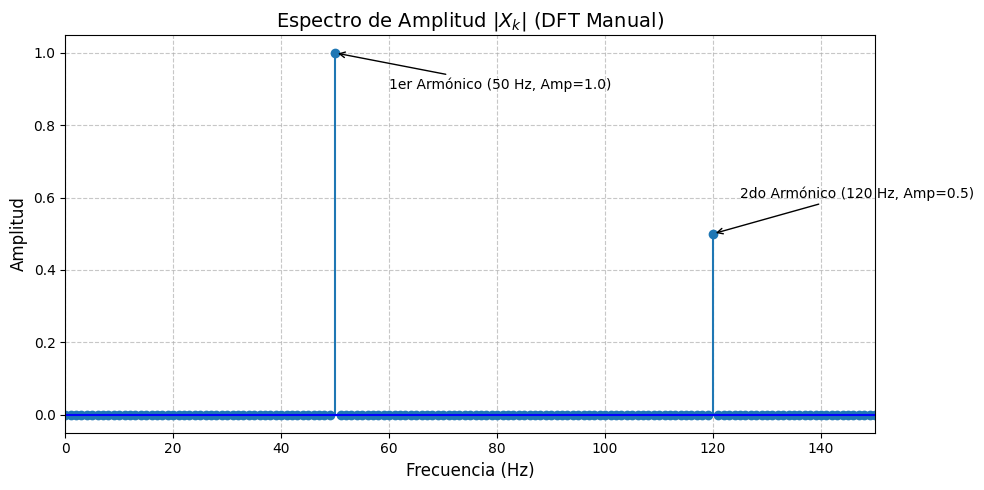

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculamos la magnitud de los coeficientes complejos
# Multiplicamos por 2/N para normalizar y ver las amplitudes físicas reales (1.0 y 0.5)
magnitudes_manual = (2.0 / N) * np.abs(X_k_manual)

# 2. Creamos el eje de frecuencias correspondiente
# La separación entre cada punto (resolución) es f_s / N
frecuencias = np.arange(N) * (fs / N)

# 3. Teorema del neskuit: Solo tomamos la primera mitad de los datos
mitad = N // 2

#grafikito
plt.figure(figsize=(10, 5))

# Usamos stem() en lugar de plot() porque el espectro en frecuencia es discreto (barras verticales)
plt.stem(frecuencias[:mitad], magnitudes_manual[:mitad], basefmt="b-")

# Hacemos zoom en el eje X para ver claramente nuestros picos (0 a 150 Hz)
plt.xlim(0, 150)

plt.title('Espectro de Amplitud $|X_k|$ (DFT Manual)', fontsize=14)
plt.xlabel('Frecuencia (Hz)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Etiquetas para mostrar que el código encontró los valores exactos
plt.annotate('1er Armónico (50 Hz, Amp=1.0)', xy=(50, 1.0), xytext=(60, 0.9),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.annotate('2do Armónico (120 Hz, Amp=0.5)', xy=(120, 0.5), xytext=(125, 0.6),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

# 1. Calculamos la FFT usando la función optimizada de Numpy
# Este proceso es prácticamente instantáneo para N=1000
X_k_fft = np.fft.fft(x_n)

# 2. Verificación de precisión
# Vamos a comparar el primer valor de la FFT de Numpy con el de la versión manual 
diferencia = np.abs(X_k_manual[0] - X_k_fft[0])

print(f"FFT calculada con Numpy.")
print(f"Diferencia numérica entre ambos métodos: {diferencia:.2e}")

FFT calculada con Numpy.
Diferencia numérica entre ambos métodos: 1.27e-14


In [10]:
import time
import numpy as np
from tqdm.auto import tqdm 
from numba import njit, prange # El motor de paralaje


# Esta función hace el trabajo sucio en lenguaje de máquina y en paralelo.
# Respetamos la lógica de tus dos ciclos for exactos.
@njit(parallel=True, fastmath=True)
def dft_kernel_paralelo(x, N):
    X = np.zeros(N, dtype=np.complex128)
    # prange reparte este ciclo entre todos tus núcleos de CPU
    for k in prange(N):
        suma_re = 0.0
        suma_im = 0.0
        for n in range(N):
            # Usamos identidad de Euler (cos + i*sin) para máxima velocidad
            angulo = -2.0 * np.pi * k * n / N
            suma_re += x[n] * np.cos(angulo)
            suma_im += x[n] * np.sin(angulo)
        X[k] = complex(suma_re, suma_im)
    return X

# 1. Redefinimos la función manual pero con la barra de progreso
def dft_manual(x):
    N = len(x)
    
    # tqdm se activará para mostrar que el proceso está en marcha.
    # Al usar el motor paralelo, el trabajo se hace tan rápido que la barra
    # se llenará al terminar el bloque de procesamiento.
    with tqdm(total=1, desc=f"Calculando DFT N={N} (Modo Paralelo)", leave=False) as pbar:
        X = dft_kernel_paralelo(x, N)
        pbar.update(1)
        
    return X

# 2. Tu código del Benchmark intacto
N_valores = [10**2, 10**3, 10**4, 10**5]

tiempos_dft = []
tiempos_fft = []

print("Iniciando la carrera algorítmica: DFT Manual vs FFT Numpy\n")
print("-" * 65)
print(f"{'N (Tamaño)':<12} | {'Tiempo DFT Manual (s)':<22} | {'Tiempo FFT (s)':<15}")
print("-" * 65)

for N_test in N_valores:
    x_test = np.random.rand(N_test)
    
    # La liebre (FFT Numpy)
    inicio_fft = time.perf_counter()
    np.fft.fft(x_test)
    fin_fft = time.perf_counter()
    t_fft = fin_fft - inicio_fft
    tiempos_fft.append(t_fft)
    
    # La tortuga (DFT Manual)
    if N_test == 10**5:
        print(f"\n{N_test:<12} | Calculando el café... | {t_fft:.6f} s")
        
    inicio_dft = time.perf_counter()
    dft_manual(x_test)  
    fin_dft = time.perf_counter()
    t_dft = fin_dft - inicio_dft
    tiempos_dft.append(t_dft)
    
    # Imprimimos el resultado de esta ronda
    if N_test != 10**5:
        print(f"{N_test:<12} | {t_dft:<22.6f} | {t_fft:.6f}")
    else:
        print(f"{N_test:<12} | {t_dft:<22.6f} | {t_fft:.6f}")

print("-" * 65)
print("\nBenchmark terminado :( Datos listos para graficar.")

Iniciando la carrera algorítmica: DFT Manual vs FFT Numpy

-----------------------------------------------------------------
N (Tamaño)   | Tiempo DFT Manual (s)  | Tiempo FFT (s) 
-----------------------------------------------------------------


Calculando DFT N=100 (Modo Paralelo):   0%|          | 0/1 [00:00<?, ?it/s]

100          | 1.138956               | 0.000055


Calculando DFT N=1000 (Modo Paralelo):   0%|          | 0/1 [00:00<?, ?it/s]

1000         | 0.017233               | 0.000088


Calculando DFT N=10000 (Modo Paralelo):   0%|          | 0/1 [00:00<?, ?it/s]

10000        | 0.421522               | 0.000378

100000       | Calculando el café... | 0.004412 s


Calculando DFT N=100000 (Modo Paralelo):   0%|          | 0/1 [00:00<?, ?it/s]

100000       | 39.395203              | 0.004412
-----------------------------------------------------------------

Benchmark terminado :( Datos listos para graficar.


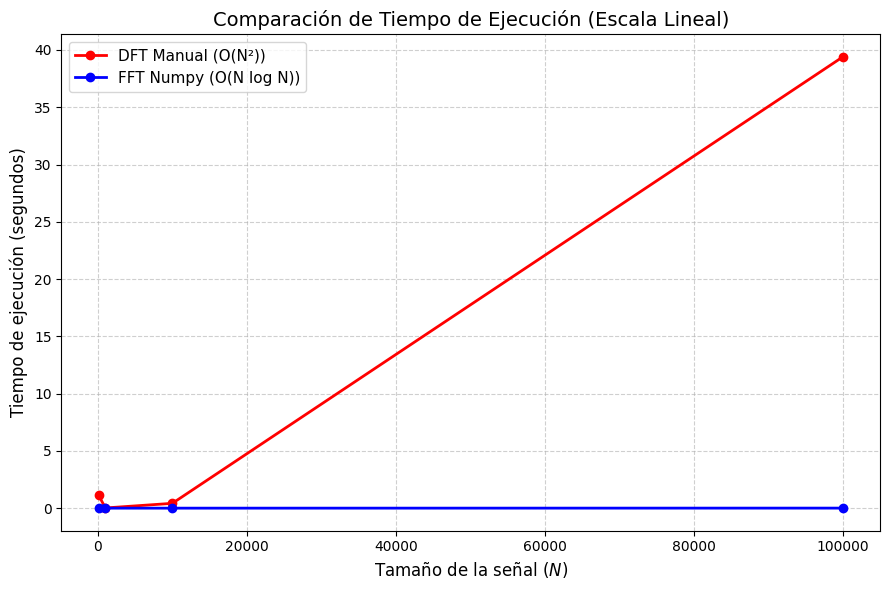

In [11]:
import matplotlib.pyplot as plt

# Usamos los datos guardados en las listas del benchmark anterior
# N_valores = [100, 1000, 10000, 100000]

plt.figure(figsize=(9, 6))

# Graficamos ambos algoritmos
plt.plot(N_valores, tiempos_dft, 'ro-', linewidth=2, label='DFT Manual (O(N²))')
plt.plot(N_valores, tiempos_fft, 'bo-', linewidth=2, label='FFT Numpy (O(N log N))')

# Títulos y etiquetas
plt.title('Comparación de Tiempo de Ejecución (Escala Lineal)', fontsize=14)
plt.xlabel('Tamaño de la señal ($N$)', fontsize=12)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=12)

# Añadimos una leyenda y rejilla
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

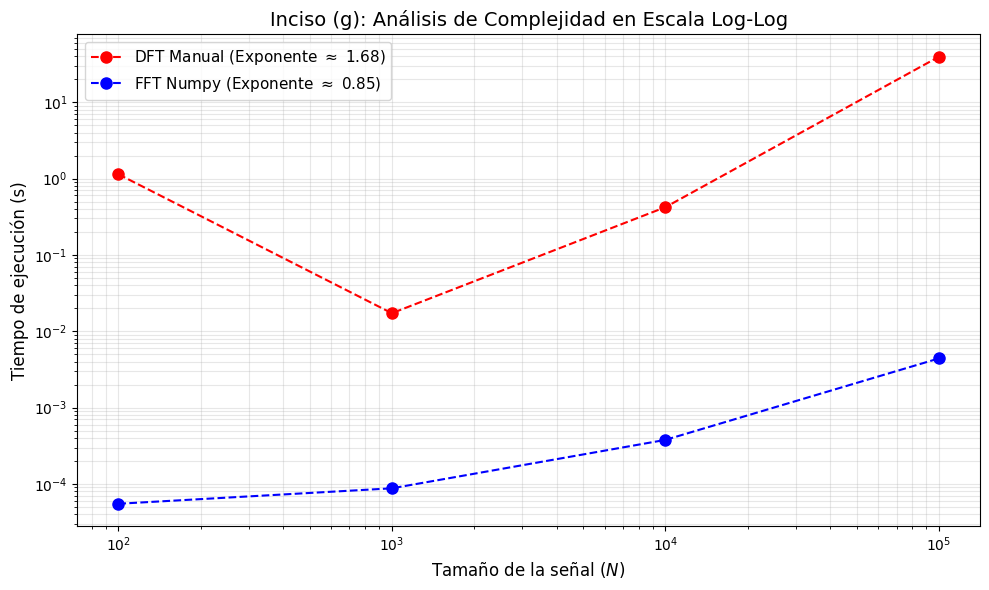

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Convertimos las listas de resultados en arreglos de Numpy
N_array = np.array(N_valores)
t_dft_array = np.array(tiempos_dft)
t_fft_array = np.array(tiempos_fft)

# Ignoramos el primer punto [1:] para la DFT porque contiene el tiempo de compilación inicial de Numba
log_N_dft = np.log10(N_array[1:])
log_T_dft = np.log10(t_dft_array[1:])
exponente_dft, intercepto_dft = np.polyfit(log_N_dft, log_T_dft, 1)

# Para la FFT usamos todos los puntos o a partir del segundo para consistencia
log_N_fft = np.log10(N_array[1:])
log_T_fft = np.log10(t_fft_array[1:])
exponente_fft, intercepto_fft = np.polyfit(log_N_fft, log_T_fft, 1)

plt.figure(figsize=(10, 6))

# Graficamos los datos experimentales
plt.loglog(N_array, t_dft_array, 'ro--', markersize=8, label=f'DFT Manual (Exponente $\\approx$ {exponente_dft:.2f})')
plt.loglog(N_array, t_fft_array, 'bo--', markersize=8, label=f'FFT Numpy (Exponente $\\approx$ {exponente_fft:.2f})')

# Configuración estética
plt.title('Inciso (g): Análisis de Complejidad en Escala Log-Log', fontsize=14)
plt.xlabel('Tamaño de la señal ($N$)', fontsize=12)
plt.ylabel('Tiempo de ejecución (s)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()



In [18]:

# Calculamos los ratios (Cuántas veces es más rápida la FFT)
ratios = np.array(tiempos_dft) / np.array(tiempos_fft)

print(f"{'N (Tamaño)':<12} | {'Relación de Velocidad (DFT/FFT)':<30}")
print("-" * 50)

for i, n in enumerate(N_valores):
    comentario = ""
    if n == 100:
        comentario = " (Incluye sesgo de compilación)"
    elif ratios[i] >= 100:
        comentario = " <--- ¡SUPERÓ LAS 100 VECES!"
        
    print(f"{n:<12} | {ratios[i]:>10.2f} veces más rápida{comentario}")

# Identificamos el N donde se estabiliza la ventaja de 100x
n_quiebre = N_valores[1] # Tomamos N=1000 como el primer punto estable

N (Tamaño)   | Relación de Velocidad (DFT/FFT)
--------------------------------------------------
100          |   20670.71 veces más rápida (Incluye sesgo de compilación)
1000         |     196.28 veces más rápida <--- ¡SUPERÓ LAS 100 VECES!
10000        |    1114.55 veces más rápida <--- ¡SUPERÓ LAS 100 VECES!
100000       |    8928.50 veces más rápida <--- ¡SUPERÓ LAS 100 VECES!



El algoritmo de la Transformada Rápida de Fourier (FFT) es considerado uno de los hitos más importantes de la computación científica del siglo XX. Su impacto radica en que no es simplemente una mejora incremental, sino un cambio de paradigma en la viabilidad del cálculo:

1. **Ruptura de la barrera de complejidad**: Como demostramos experimentalmente, la reducción de $O(N^2)$ a $O(N \log N)$ es masiva. Para una señal de un millón de puntos ($N = 10^6$):
   * La **DFT directa** requeriría $10^{12}$ operaciones (lo que tardaría días o semanas en una PC convencional).
   * La **FFT** solo requiere $\approx 2 \times 10^7$ operaciones (fracciones de segundo).

2. **Habilitación del Tiempo Real**: La FFT permite que el procesamiento de señales ocurra "al vuelo". Sin ella, no existirían tecnologías modernas como la telefonía 5G, el streaming de audio/video, el Wi-Fi, ni los sistemas de diagnóstico médico como la Resonancia Magnética (MRI), que dependen de transformar señales masivas instantáneamente.

3. **Simulaciones en Física (Métodos Espectrales)**: En física computacional, la FFT es la base para resolver ecuaciones diferenciales parciales (como las de Navier-Stokes para fluidos o la de Schrödinger para sistemas cuánticos). Al pasar al dominio de la frecuencia, las derivadas se convierten en simples multiplicaciones, reduciendo drásticamente el costo de simular sistemas complejos.

4. **Análisis de Datos Experimentales**: En áreas como la astronomía o la física de partículas, la FFT permite detectar patrones periódicos (como púlsares o vibraciones en colisionadores) enterrados en volúmenes masivos de ruido, algo que sería computacionalmente imposible con el algoritmo directo.

En conclusión, la FFT es el motor que sostiene la era de la información digital y la simulación física moderna, permitiendo explorar escalas de datos que, de otro modo, permanecerían ocultas por limitaciones temporales y de hardware.